<a href="https://colab.research.google.com/github/taylan-sen/CIS490b_computer_vision/blob/main/facedetection_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☺☻ Face Detection ☻☺
### → with Haar-like features and cascade classifiers!

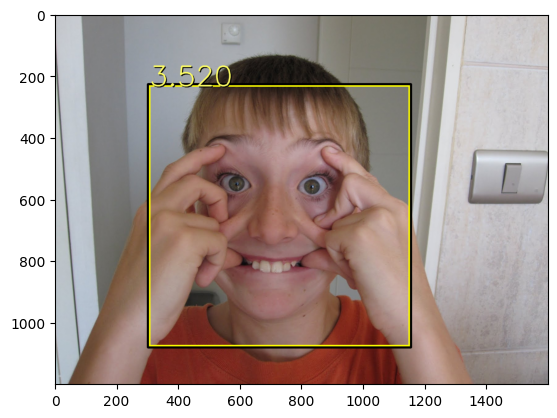

With this notebook we will learn about:
* The Haar wavelet and Haar-like features
* Ensemble Methods
* Cascade Classifiers
* The Viola-Jones face detection technique
* the python urllib module

### Motivation

Earlier we used the ***Fourier Transform*** to analyze the diferent frequency content of signals and images (recall the graphic equalizer for music).  A limitation of Fourier analysis is that it can't model sharp discontinuities well (i.e. edges).  

In summary, the Fourier Transform "rewrites" a sund clip or image as a sum of a series of Sine and Cosine functions of multiples of a base frequency, each having the specific strength (amplitude), in order to best recreate the original signal.  The Sine wave and Cosine wave are not ***localized***, in other words, they don't occur at a specific time, rather they are assumed to exist for all time.  This results in difficulty in modeling edges and leads to weird behavior at the endges of a sound clip being analyzed.  

Wavelets uses a similar concept of decomposing a sound clip or image into a sum of subsignals, but the basis function is not a series of sines and cosines of increasing frequency. Instead, wavelets finds a series of scaled mini-basis functions of varying amplitude and stretch. Unlike a sine or cosine that goes on forever, a wavelet basis function is time limited.  

The simplest wavelet basis function is the Haar wavelet.

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTaYXf-fO4J1H7ejRrq894cLIjAj0skxuBAFA&s)


For more info on wavelets, see [video](https://www.youtube.com/watch?v=cQ5cCKtOBGY).



QUESTIONS

What is a wavelet?

Why do we use wavelets?

What is OpenCV's CascadeClassifier?  

What about its member function detectMultiScale?





In [ ]:
# Download the Haar frontal face model.
!wget https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml


--2023-10-25 17:59:48--  https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.06s   

2023-10-25 17:59:48 (15.2 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]



In [ ]:
!wget https://i.pinimg.com/originals/17/ce/98/17ce9857598f61a9b3e8e1cc7fa6f921.jpg -O pigfaces.jpg

--2023-10-25 17:59:49--  https://i.pinimg.com/originals/17/ce/98/17ce9857598f61a9b3e8e1cc7fa6f921.jpg
Resolving i.pinimg.com (i.pinimg.com)... 146.75.76.84, 2600:1418:a000:11::17c8:85e5, 2600:1418:a000:11::17c8:85f5
Connecting to i.pinimg.com (i.pinimg.com)|146.75.76.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56697 (55K) [image/jpeg]
Saving to: ‘pigfaces.jpg’

pigfaces.jpg        100%[===================>]  55.37K  --.-KB/s    in 0.01s   

2023-10-25 17:59:49 (4.25 MB/s) - ‘pigfaces.jpg’ saved [56697/56697]



In [ ]:
!wget https://c8.alamy.com/comp/DY3YN6/several-kids-making-funny-faces-DY3YN6.jpg
!mv several-kids-making-funny-faces-DY3YN6.jpg kids.jpg

--2023-10-25 17:59:49--  https://c8.alamy.com/comp/DY3YN6/several-kids-making-funny-faces-DY3YN6.jpg
Resolving c8.alamy.com (c8.alamy.com)... 52.84.125.106, 52.84.125.44, 52.84.125.30, ...
Connecting to c8.alamy.com (c8.alamy.com)|52.84.125.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [image/jpeg]
Saving to: ‘several-kids-making-funny-faces-DY3YN6.jpg’

several-kids-making     [ <=>                ] 171.58K  --.-KB/s    in 0.04s   

Last-modified header invalid -- time-stamp ignored.
2023-10-25 17:59:49 (4.39 MB/s) - ‘several-kids-making-funny-faces-DY3YN6.jpg’ saved [175701]



In [ ]:
!wget https://i0.wp.com/sefiks.com/wp-content/uploads/2018/09/katy-perry-facenet.jpg
!mv 'katy-perry-facenet.jpg' test.jpg

--2023-10-25 17:59:49--  https://i0.wp.com/sefiks.com/wp-content/uploads/2018/09/katy-perry-facenet.jpg
Resolving i0.wp.com (i0.wp.com)... 192.0.77.2
Connecting to i0.wp.com (i0.wp.com)|192.0.77.2|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382202 (373K) [image/jpeg]
Saving to: ‘katy-perry-facenet.jpg’

katy-perry-facenet. 100%[===================>] 373.24K  --.-KB/s    in 0.1s    

2023-10-25 17:59:49 (2.75 MB/s) - ‘katy-perry-facenet.jpg’ saved [382202/382202]



faces: [[184  53 299 299]
 [ 25 195 194 194]
 [502 421  70  70]
 [118 489  64  64]]


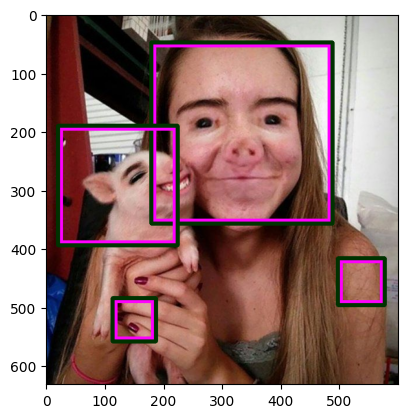

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Load the cascade
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
# Read the input image
#img = cv2.imread('test.jpg')
img = cv2.imread('kids.jpg')
img = cv2.imread('pigfaces.jpg')
# Convert into grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray)
# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 4)
print('faces:', faces)
# Draw rectangle around the faces
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 255), 5)
    cv2.rectangle(img, (x-5, y-5), (x+w+5, y+h+5), (0, 50, 0), 5)
# Display the output
#print('img:', img.shape)
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img2)
plt.show()

In [ ]:
import urllib.request
urllib.request.urlretrieve('https://i.pinimg.com/originals/17/ce/98/17ce9857598f61a9b3e8e1cc7fa6f921.jpg', 'file.jpg')

('file.jpg', <http.client.HTTPMessage at 0x7e1596f736a0>)

In [1]:
import urllib.request

def find_faces(img_url):
  urllib.request.urlretrieve(img_url, 'file.jpg')
  face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
  # Read the input image
  img = cv2.imread('file.jpg')
  # Convert into grayscale
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  plt.imshow(gray)
  # Detect faces
  faces, reject_levels, weights = face_cascade.detectMultiScale3(gray, 1.1, 4, outputRejectLevels=True)
  print('faces:', faces)
  # Draw rectangle around the faces
  for (x, y, w, h), weight in zip(faces, weights):
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 255), 5)
    cv2.rectangle(img, (x-5, y-5), (x+w+5, y+h+5), (0, 0, 0), 5)
    #cv2.putText(img, weight, (x,y)), font,
    #               fontScale, color, thickness, cv2.LINE_AA)
    cv2.putText(img, f"{weight:.3f}", (x+3,y+3), cv2.FONT_HERSHEY_SIMPLEX,3,
              (0,0,0), 3, cv2.LINE_AA)
    cv2.putText(img, f"{weight:.3f}", (x,y), cv2.FONT_HERSHEY_SIMPLEX,3,
              (100,255,255), 3, cv2.LINE_AA)
    print('weights:', weight)
  # Display the output
  #print('img:', img.shape)
  img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.imshow(img2)
  plt.show()
#find_faces('https://cdn.acidcow.com/pics/20091117/hdr_faces_32.jpg')
find_faces('http://2.bp.blogspot.com/_pShGhsG9wW4/TR-NupniIzI/AAAAAAAADpk/PYnc8fvmS-U/s1600/IMG_4607.JPG')
find_faces('https://pagesix.com/wp-content/uploads/sites/3/2020/03/katy-perry-orlando-bloom.jpg')
find_faces('https://ychef.files.bbci.co.uk/1280x720/p0lq9155.webp')

NameError: name 'cv2' is not defined

###Wavelets and Haar-like features

What is a wavelet? How is it different from a sine wave, and why is being "localized" in both position and scale useful for analyzing images?
What is the Haar wavelet specifically? Sketch it. Why is it called the simplest possible wavelet?
How does a wavelet transform differ from a Fourier transform in what it tells you about an image?
What is a Haar-like feature? Draw the two-rectangle, three-rectangle, and four-rectangle versions. How do they relate to the Haar wavelet?
How is the value of a Haar-like feature computed from pixel intensities? What facial patterns might a horizontal two-rectangle feature respond to (hint: eyes vs. cheeks)?
What is an integral image (summed-area table), and why does it let you compute any rectangle sum with only four lookups?
A 24×24 detection window has over 160,000 possible Haar-like features. Why can't the detector evaluate all of them, and how does training pick the useful ones?

Ensemble methods and cascade classifiers
8. What is a weak classifier versus a strong classifier? Why is a single Haar-like feature a weak classifier?
9. What is an ensemble method? How does AdaBoost combine many weak classifiers, and how does it decide each one's weight?
10. What is a cascade classifier? Why does arranging classifiers in stages make detection so fast?
11. In a cascade, why is it acceptable for early stages to have many false positives but nearly zero false negatives?
12. What is in haarcascade_frontalface_default.xml? Open it and identify the stages, features, and thresholds. Who trained it and on what kind of data?

Viola-Jones and the code
13. What were Viola and Jones's three main contributions in their 2001 paper, and why was real-time face detection a big deal then?
14. Why does the code convert the image to grayscale before detection? What information is lost, and why doesn't the detector need it?
15. Why does cv2.imread give BGR instead of RGB, and why does the code call cv2.cvtColor(img, cv2.COLOR_BGR2RGB) before plt.imshow?
16. When plt.imshow(gray) displays the grayscale image, why does it appear in green and purple? What argument would fix that?
17. In detectMultiScale(gray, 1.1, 4), what do scaleFactor=1.1 and minNeighbors=4 control? Predict what happens if you change them to 1.3 and 1, then test it.

18. How does the detector find faces of different sizes if it was trained on a fixed window size? What is an image pyramid?

19. What does detectMultiScale return, and what do x, y, w, h mean in image coordinates? Where is the origin?

20. In cell 8, img is assigned twice in a row. Which image actually gets processed, and why?

21. What do the reject_levels and weights returned by detectMultiScale3 represent? Is a higher weight a probability? How confident should we be in a detection with a low weight?

Testing limits and failure modes

22. Run the detector on pigfaces.jpg. Does it find pig faces? Why or why not, given what the cascade was trained on?
23. Try faces that are tilted, in profile, partially covered, or making funny expressions (kids.jpg). Which ones does it miss, and what does that tell you about Haar features?
24. Find an image that produces a false positive (a "face" that isn't one). What visual pattern fooled it?
25. How does lighting affect detection? Why are Haar features somewhat robust to uniform brightness changes but not to strong shadows?

urllib and the pipeline
26. What does urllib.request.urlretrieve do, and how is it different from the !wget shell commands earlier in the notebook?
27. Why might find_faces crash on some URLs? Add error handling for a failed download or for cv2.imread returning None.

Bigger picture
28. How do modern deep learning face detectors (e.g., MTCNN, RetinaFace, YOLO-based detectors) differ from Viola-Jones? What did we gain, and what did we give up in speed and interpretability?
29. What is the difference between face detection, face recognition, and face verification?
30. Research documented accuracy disparities in face detection and recognition across skin tones, ages, and genders (e.g., the Gender Shades study). Where in a pipeline like this one could bias enter?